In [3]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models

strategy = tf.distribute.MirroredStrategy()
num_gpus = strategy.num_replicas_in_sync
print(f'\n🎯 Perfect! Training is distributed across {num_gpus} GPUs for Maximum Accuracy!\n')

# التعديل الصحيح للسطر رقم 12:
GLOBAL_BATCH_SIZE = 32 * num_gpus

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')

🎯 Perfect! Training is distributed across 2 GPUs for Maximum Accuracy!



In [4]:
# import os
# for root, dirs, files in os.walk("/kaggle/input/"):
#     
#     if root.count(os.sep) <= 6: 
#         print(root)

In [5]:
BASE_DIR = "/kaggle/input/datasets/rawanelmorsy/emora-images"

train_dataset = image_dataset_from_directory(
    os.path.join(BASE_DIR, "train"),
    image_size=(224, 224),
    batch_size=GLOBAL_BATCH_SIZE,  # تم التحديث هنا للـ Global Batch
    color_mode='rgb'
)

val_dataset = image_dataset_from_directory(
    os.path.join(BASE_DIR, "val"),
    image_size=(224, 224),
    batch_size=GLOBAL_BATCH_SIZE,
    color_mode='rgb'
)

test_dataset = image_dataset_from_directory(
    os.path.join(BASE_DIR, "test"),
    image_size=(224, 224),
    batch_size=GLOBAL_BATCH_SIZE,
    color_mode='rgb'
)

class_names = train_dataset.class_names
print("Classes identified:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 45304 files belonging to 7 classes.
Found 11326 files belonging to 7 classes.
Found 6286 files belonging to 7 classes.
Classes identified: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


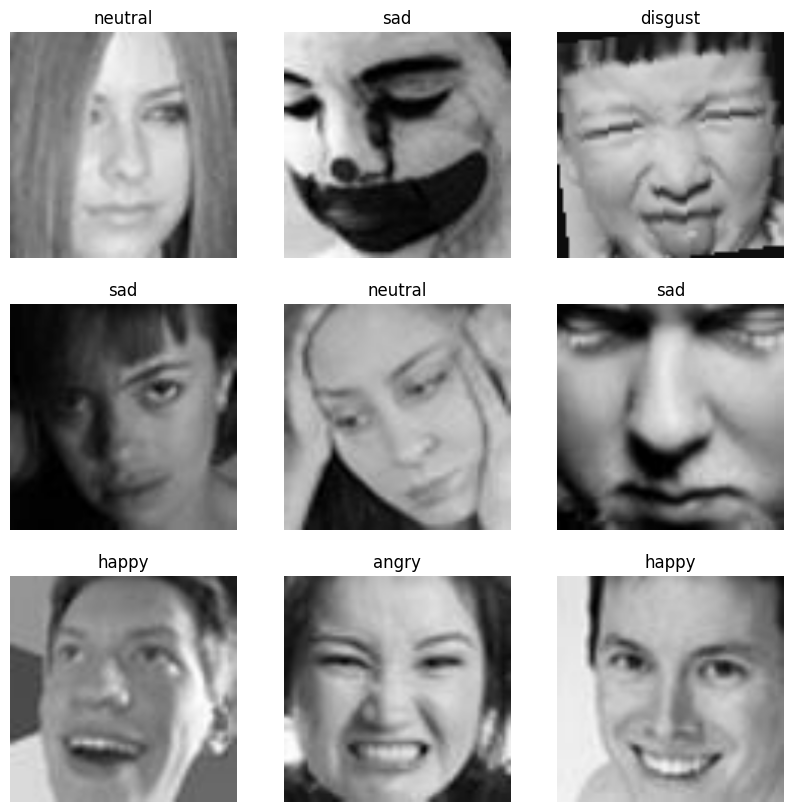

In [6]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20), # زيادة طفيفة لمرونة الحركة
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.15), # تحسين التعامل مع الظلال والإضاءة الخافتة
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1) # حركات ذكية لالتقاط زوايا الوجه
])

In [8]:
with strategy.scope():
    
    # استدعاء الوحش ResNet50V2 بدلاً من MobileNetV2 الخفيف
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # تجميد أولي

    # الهيكل الاحترافي الجديد لرفع الـ Capacity وتأمين الأوزان الصافية بره
    model = models.Sequential([
        data_augmentation,
        
        # طبقة تحجيم حسابية صريحة ومتوافقة 100% مع الـ Preprocessing لـ ResNet50V2
        layers.Rescaling(1./127.5, offset=-1.0), 
        
        base_model,
        layers.GlobalAveragePooling2D(),
        
        # تضخيم شبكة الاتصال لالتقاط الملامح المعقدة للكبار والأطفال
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),  # تسرع التوافق الحسابي وترفع الـ Accuracy
        layers.Dropout(0.5),          # حماية عنيفة من الـ Overfitting
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), # LR مثالي للـ ResNet في البداية
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4, # زيادة الفرصة للموديل الثقيل ليتعلم
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/kaggle/working/best_model.keras', 
    save_best_only=True,
    monitor='val_loss'
)

In [10]:
print("\n🚀 Starting Phase 1: Training Custom Classification Head...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset, 
    epochs=10, # 10epochs كافية جداً لضبط المفاصل الجديدة
    callbacks=[early_stop, reduce_lr, checkpoint]
)

model.save('/kaggle/working/emergency_save.keras') 

# =====================================================================
# BLOCK 8: PHASE 2 TRAINING (Advanced Fine-Tuning)
# =====================================================================
print("\n🔓 Unfreezing Deep ResNet Layers for Advanced Fine-Tuning...")
base_model.trainable = True

# فتح آخر 30 طبقة فقط من الـ ResNet لضبط الملامح الدقيقة جداً لـ Emora
for layer in base_model.layers[:-30]:
    layer.trainable = False

# الـ Compile الثاني داخل الـ strategy مع الـ Learning Rate الهادئ جداً
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # LR هادئ لمنع تدمير الأوزان الذكية
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("\n🚀 Starting Phase 2: Advanced Fine-Tuning...")
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,  
    epochs=20, # مساحة أكبر للـ ResNet للوصول لأعلى Accuracy ممكنة
    callbacks=[early_stop, reduce_lr, checkpoint]
)


🚀 Starting Phase 1: Training Custom Classification Head...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:loca

I0000 00:00:1779713848.385438     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779713848.909157     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


708/708 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2239 - loss: 2.4462INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
708/708 ━━━━━━━━━━━━━━━━━━━━ 142s 178ms/step - accuracy: 0.2239 - loss: 2.4460 - val_accuracy: 0.3933 - val_loss: 1.6221 - learning_rate: 1.0000e-04
Epoch 2/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 126s 177ms/step - accuracy: 0.2941 - loss: 2.0047 - val_accuracy: 0.4167 - val_loss: 1.5381 - learning_rate: 1.0000e-04
Epoch 3/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 126s 178ms/step - accuracy: 0.3185 - loss: 1.8613 - val_accuracy: 0.4327 - val_loss: 1.4933 - learning_rate: 1.0000e-04
Epoch 4/10
708/708 ━━━━━━━━━━━━━━━━━━━━ 127s 179ms/step - accuracy: 0.3478 - loss: 1.7635 - val_accuracy: 0.4490 - val_loss: 1.4609 - learning_rate: 1.0000e-04
Epoch 5/10
708/

In [11]:
print("\n--- Final Evaluation on Test Dataset ---")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"🥇 Ultimate Test Accuracy: {test_acc*100:.2f}%")

# حفظ الأكواد والملفات بالصيغ الرسمية المتوافقة مع سكريبتات التست بره
model.save_weights('/kaggle/working/emora_pure_weights.weights.h5')
model.save('/kaggle/working/emora_legacy_model.h5')

print("\n🎉 Beautiful! All high-accuracy secure formats saved successfully to /kaggle/working/ !")


--- Final Evaluation on Test Dataset ---
99/99 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.6830 - loss: 0.8420
🥇 Ultimate Test Accuracy: 67.45%



🎉 Beautiful! All high-accuracy secure formats saved successfully to /kaggle/working/ !
